In [1]:
import pandas as pd
import numpy as np
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
housing = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
housing.head()        

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [128]:
housing.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 1460 entries, 0 to 1459

Data columns (total 81 columns):

 #   Column         Non-Null Count  Dtype  

---  ------         --------------  -----  

 0   Id             1460 non-null   int64  

 1   MSSubClass     1460 non-null   int64  

 2   MSZoning       1460 non-null   object 

 3   LotFrontage    1201 non-null   float64

 4   LotArea        1460 non-null   int64  

 5   Street         1460 non-null   object 

 6   Alley          91 non-null     object 

 7   LotShape       1460 non-null   object 

 8   LandContour    1460 non-null   object 

 9   Utilities      1460 non-null   object 

 10  LotConfig      1460 non-null   object 

 11  LandSlope      1460 non-null   object 

 12  Neighborhood   1460 non-null   object 

 13  Condition1     1460 non-null   object 

 14  Condition2     1460 non-null   object 

 15  BldgType       1460 non-null   object 

 16  HouseStyle     1460 non-null   object 

 17  OverallQual    1460 non-null  

In [129]:
housing.drop(columns=['Alley','PoolQC','MiscFeature','Fence'], inplace=True)
housing.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD

In [130]:
housing.set_index('Id', inplace=True)
housing.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [131]:
categorical_columns = ['MSSubClass','MSZoning','Street','LotShape','LandContour','Utilities', 'BedroomAbvGr',
                       'LotConfig','Foundation','LandSlope','Neighborhood','Condition1','Condition2','BldgType',
                       'HouseStyle','OverallQual','OverallCond','YearBuilt','YearRemodAdd','RoofStyle',
                       'RoofMatl','Exterior1st','Exterior2nd','MasVnrType','ExterQual','ExterCond','BsmtQual',
                       'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir',
                       'Electrical','KitchenQual','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','Functional',
                       'FireplaceQu','GarageCars','GarageType','GarageYrBlt','GarageFinish','GarageQual','GarageCond',
                       'PavedDrive','MoSold','YrSold','SaleType','SaleCondition','KitchenAbvGr','Fireplaces','TotRmsAbvGrd']
housing[categorical_columns].shape

(1460, 56)

In [150]:
missing_val_columns = {}
housing_col_missing_values = (housing.isnull().sum())
for c, v in housing_col_missing_values[housing_col_missing_values > 0].items():
    if c in categorical_columns:
        missing_val_columns['Categorical -> ' + c] = v
    else:
        missing_val_columns['Numerical -> ' + c] = v

sorted_columns_by_missing_values = sorted(missing_val_columns.items(), key=lambda x:x[1], reverse=True)
print(sorted_columns_by_missing_values)


[('Categorical -> MasVnrType', 872), ('Categorical -> FireplaceQu', 690), ('Numerical -> LotFrontage', 259), ('Categorical -> GarageType', 81), ('Categorical -> GarageYrBlt', 81), ('Categorical -> GarageFinish', 81), ('Categorical -> GarageQual', 81), ('Categorical -> GarageCond', 81), ('Categorical -> BsmtExposure', 38), ('Categorical -> BsmtFinType2', 38), ('Categorical -> BsmtQual', 37), ('Categorical -> BsmtCond', 37), ('Categorical -> BsmtFinType1', 37), ('Numerical -> MasVnrArea', 8), ('Categorical -> Electrical', 1)]


In [159]:
numerical_attributes = housing.loc[:,~housing.columns.isin(categorical_columns)].drop('SalePrice', axis=1)

In [160]:
numerical_attributes.head()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
Id,,,,,,,,,,,,,,,,,,,
1,65.0,8450,196.0,706,0,150,856,856,854,0,1710,548,0,61,0,0,0,0,0
2,80.0,9600,0.0,978,0,284,1262,1262,0,0,1262,460,298,0,0,0,0,0,0
3,68.0,11250,162.0,486,0,434,920,920,866,0,1786,608,0,42,0,0,0,0,0
4,60.0,9550,0.0,216,0,540,756,961,756,0,1717,642,0,35,272,0,0,0,0
5,84.0,14260,350.0,655,0,490,1145,1145,1053,0,2198,836,192,84,0,0,0,0,0


In [161]:
corr_matrix = housing.loc[:,~housing.columns.isin(categorical_columns)].corr()
corr_matrix['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
GrLivArea        0.708624
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
MasVnrArea       0.477493
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
LotArea          0.263843
BsmtUnfSF        0.214479
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
MiscVal         -0.021190
LowQualFinSF    -0.025606
EnclosedPorch   -0.128578
Name: SalePrice, dtype: float64

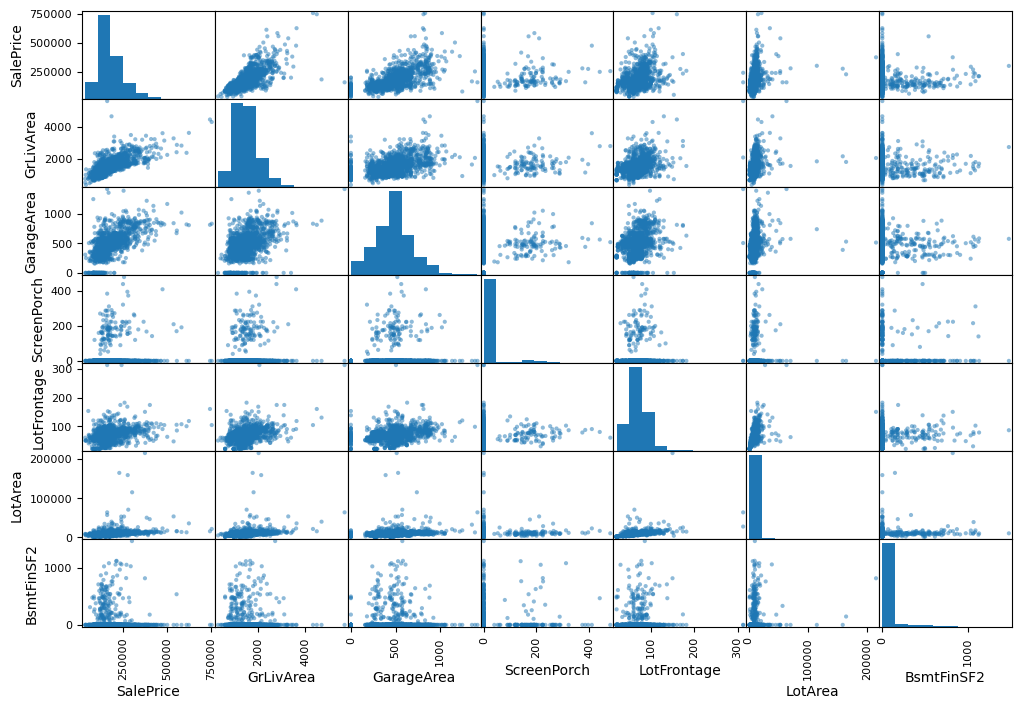

In [162]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = ['SalePrice', 'GrLivArea', 'GarageArea', 'ScreenPorch','LotFrontage', 'LotArea','BsmtFinSF2']
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

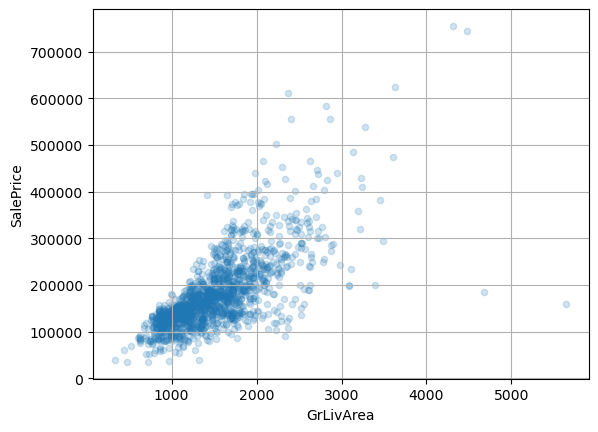

In [163]:
housing.plot(kind="scatter", x='GrLivArea', y='SalePrice', alpha=0.2, grid=True)

In [164]:
numerical_attributes.columns

Index(['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype='object')

In [165]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [166]:
X = imputer.fit_transform(numerical_attributes)
numerical_attributes.head()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
Id,,,,,,,,,,,,,,,,,,,
1,65.0,8450,196.0,706,0,150,856,856,854,0,1710,548,0,61,0,0,0,0,0
2,80.0,9600,0.0,978,0,284,1262,1262,0,0,1262,460,298,0,0,0,0,0,0
3,68.0,11250,162.0,486,0,434,920,920,866,0,1786,608,0,42,0,0,0,0,0
4,60.0,9550,0.0,216,0,540,756,961,756,0,1717,642,0,35,272,0,0,0,0
5,84.0,14260,350.0,655,0,490,1145,1145,1053,0,2198,836,192,84,0,0,0,0,0


In [167]:
housing_tr = pd.DataFrame(X,columns=numerical_attributes.columns, index=numerical_attributes.index)
housing_tr.head()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
Id,,,,,,,,,,,,,,,,,,,
1,65.0,8450.0,196.0,706.0,0.0,150.0,856.0,856.0,854.0,0.0,1710.0,548.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0
2,80.0,9600.0,0.0,978.0,0.0,284.0,1262.0,1262.0,0.0,0.0,1262.0,460.0,298.0,0.0,0.0,0.0,0.0,0.0,0.0
3,68.0,11250.0,162.0,486.0,0.0,434.0,920.0,920.0,866.0,0.0,1786.0,608.0,0.0,42.0,0.0,0.0,0.0,0.0,0.0
4,60.0,9550.0,0.0,216.0,0.0,540.0,756.0,961.0,756.0,0.0,1717.0,642.0,0.0,35.0,272.0,0.0,0.0,0.0,0.0
5,84.0,14260.0,350.0,655.0,0.0,490.0,1145.0,1145.0,1053.0,0.0,2198.0,836.0,192.0,84.0,0.0,0.0,0.0,0.0,0.0


In [168]:
housing_tr.isnull().sum()

LotFrontage      0
LotArea          0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
dtype: int64

In [169]:
housing_cat = housing[categorical_columns]
housing_cat.head()

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,BedroomAbvGr,LotConfig,Foundation,LandSlope,...,GarageQual,GarageCond,PavedDrive,MoSold,YrSold,SaleType,SaleCondition,KitchenAbvGr,Fireplaces,TotRmsAbvGrd
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,Reg,Lvl,AllPub,3,Inside,PConc,Gtl,...,TA,TA,Y,2,2008,WD,Normal,1,0,8
2,20,RL,Pave,Reg,Lvl,AllPub,3,FR2,CBlock,Gtl,...,TA,TA,Y,5,2007,WD,Normal,1,1,6
3,60,RL,Pave,IR1,Lvl,AllPub,3,Inside,PConc,Gtl,...,TA,TA,Y,9,2008,WD,Normal,1,1,6
4,70,RL,Pave,IR1,Lvl,AllPub,3,Corner,BrkTil,Gtl,...,TA,TA,Y,2,2006,WD,Abnorml,1,1,7
5,60,RL,Pave,IR1,Lvl,AllPub,4,FR2,PConc,Gtl,...,TA,TA,Y,12,2008,WD,Normal,1,1,9


In [173]:
missing_val_count_by_column = (housing_cat.isna().sum())
missing_val_count_by_column[missing_val_count_by_column > 0]

MasVnrType      872
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [176]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [182]:
ordinal_encoder.categories_


[array([ 20,  30,  40,  45,  50,  60,  70,  75,  80,  85,  90, 120, 160,
        180, 190]),
 array(['C (all)', 'FV', 'RH', 'RL', 'RM'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['IR1', 'IR2', 'IR3', 'Reg'], dtype=object),
 array(['Bnk', 'HLS', 'Low', 'Lvl'], dtype=object),
 array(['AllPub', 'NoSeWa'], dtype=object),
 array([0, 1, 2, 3, 4, 5, 6, 8]),
 array(['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'], dtype=object),
 array(['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood'], dtype=object),
 array(['Gtl', 'Mod', 'Sev'], dtype=object),
 array(['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr',
        'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel',
        'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown',
        'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber',
        'Veenker'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNe',
        'RRNn'], dtype=object),
 arra